In [25]:
import pandas as pd
from Functions import clean_titanic_data

In [26]:
data_train = pd.read_csv("./Datasets/Titanic/train.csv")
data_test_x = pd.read_csv("./Datasets/Titanic/test.csv")
data_test_y = pd.read_csv("./Datasets/Titanic/gender_submission.csv")

In [27]:
cleaned_data_train = clean_titanic_data(data_train)
print(cleaned_data_train.to_string())

     Survived  Pclass  isFemale    Age  SibSp  Parch      Fare  Cabin  Embarked  Ticket Group Size
0           0       3         0  22.00      1      0    7.2500    147         2                  1
1           1       1         1  38.00      1      0   71.2833     81         0                  1
2           1       3         1  26.00      0      0    7.9250    147         2                  1
3           1       1         1  35.00      1      0   53.1000     55         2                  2
4           0       3         0  35.00      0      0    8.0500    147         2                  1
5           0       3         0  30.00      0      0    8.4583    147         1                  1
6           0       1         0  54.00      0      0   51.8625    129         2                  1
7           0       3         0   2.00      3      1   21.0750    147         2                  4
8           1       3         1  27.00      0      2   11.1333    147         2                  3
9         

# --------------------------

# Training The Model

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Seperating x & y

In [29]:
x_train = cleaned_data_train.drop("Survived", axis="columns").to_numpy()
y_train = cleaned_data_train['Survived'].to_numpy()

print(x_train, '\n', y_train)


[[  3.   0.  22. ... 147.   2.   1.]
 [  1.   1.  38. ...  81.   0.   1.]
 [  3.   1.  26. ... 147.   2.   1.]
 ...
 [  3.   1.  30. ... 147.   2.   2.]
 [  1.   0.  26. ...  60.   0.   1.]
 [  3.   0.  32. ... 147.   1.   1.]] 
 [0 1 1 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 1 1 1 0 1 0 0 1 0 0 1 1 0 0 0 1
 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 1 1 0 1 1 0 1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0
 1 0 0 0 1 1 0 1 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 1 0
 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1
 0 1 1 0 0 1 0 1 1 1 1 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 1 0
 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 1
 1 0 1 0 0 0 0 0 1 1 1 0 1 1 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 1 1 1 1 0 0 0 0
 0 0 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 1 0 1 0 1 1 1 1 0 0
 0 1 0 0 1 1 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 1 1 1
 1 0 0 0 0 1 1 0 0 0

## Plotting the data

In [30]:
import matplotlib.pyplot as plt

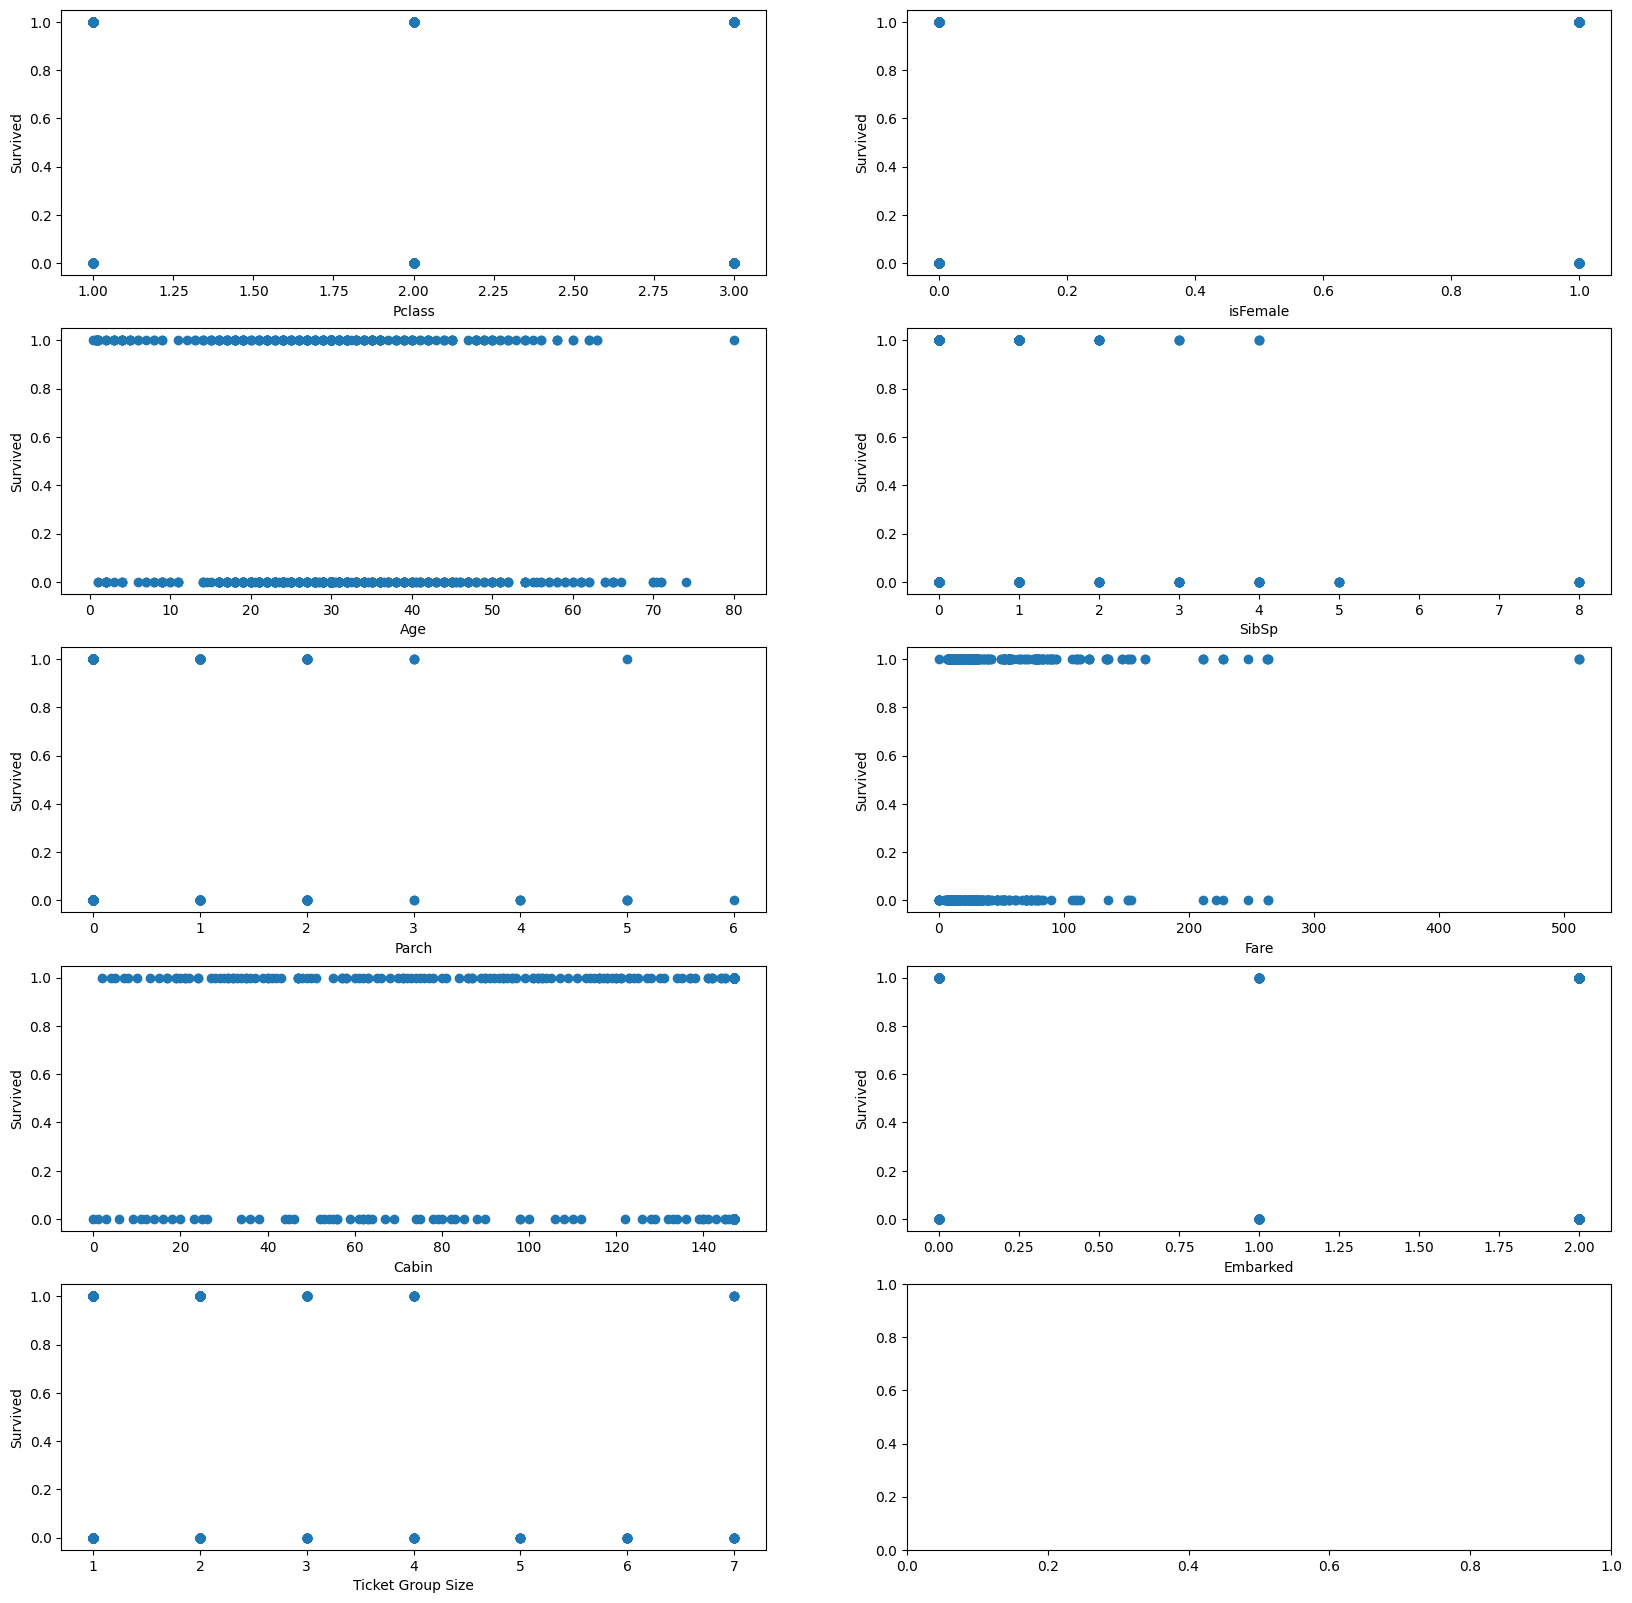

In [31]:
features = list(cleaned_data_train.columns.values)
features.remove("Survived")


fig, plot = plt.subplots(5, 2, figsize=(20, 20))
plot = plot.ravel()

for i in range(9):
    plot[i].scatter(x_train[:, i], y_train)
    plot[i].set_xlabel(features[i])
    plot[i].set_ylabel('Survived')

## Data Scaling

In [32]:
scaler = StandardScaler().fit(x_train)

x_train_scaled = scaler.transform(x_train)

print(x_train_scaled)

[[ 0.82737724 -0.73769513 -0.59705478 ...  0.45150219  0.58595414
  -0.57916179]
 [-1.56610693  1.35557354  0.63416229 ... -1.38162664 -1.9423032
  -0.57916179]
 [ 0.82737724  1.35557354 -0.28925051 ...  0.45150219  0.58595414
  -0.57916179]
 ...
 [ 0.82737724  1.35557354  0.01855376 ...  0.45150219  0.58595414
   0.15592818]
 [-1.56610693 -0.73769513 -0.28925051 ... -1.9648949  -1.9423032
  -0.57916179]
 [ 0.82737724 -0.73769513  0.17245589 ...  0.45150219 -0.67817453
  -0.57916179]]


In [33]:
l_regr = LogisticRegression()
l_regr.fit(x_train, y_train)

print(l_regr.score(x_train, y_train))

0.797979797979798


C:\Users\Persian\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Setting up Tests

In [34]:
x_test = clean_titanic_data(data_test_x) #.to_numpy()

y_test = data_test_y["Survived"]

In [36]:
y_predict = l_regr.predict(x_test)

C:\Users\Persian\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [37]:
mse = mean_squared_error(y_test, y_predict)

mse

0.05502392344497608